# Exercise 6: Missing Data

**Authors**: 
- Ariful Islam Riane : 3981886
- Pedro Fernandez Tonso : 3983781
- Group Number : 19

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)

## 1. Load and Prepare Data

In [2]:
def load_arff(file_path):
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

file_path = Path('../databank/00_raw/uci-large/credit-a.arff')
if not file_path.exists():
    file_path = Path('dq-lab-1/databank/00_raw/uci-large/credit-a.arff')

data, _ = load_arff(file_path)
data.dropna(inplace=True)

for col, typ in zip(data.columns, data.dtypes):
    if typ == 'object':
        data[col] = data[col].map(lambda x: x.decode() if isinstance(x, bytes) else x)

X = pd.get_dummies(data.drop('class', axis=1))
X = X.drop([col for col in X.columns if col.endswith('_?')], axis=1)
y = data['class']

## 2. Missing Data Experiment Functions

In [3]:
BASE_COLS = X.columns  # one-hot layout of the clean data


def encode(df):
    """One-hot encode a raw dataframe onto the fixed baseline column layout."""
    return pd.get_dummies(df.drop('class', axis=1)).reindex(columns=BASE_COLS, fill_value=0)


# One fixed 70/30 split. The test set is never corrupted: every run below trains on a
# corrupted-then-cleaned copy of TRAIN_FULL and is scored on this same clean benchmark,
# so accuracy differences reflect the cleaning strategy, not a moving target.
train_idx, test_idx = train_test_split(
    data.index, train_size=0.7, test_size=0.3, random_state=100
)
TRAIN_FULL = data.loc[train_idx]
TEST_CLEAN = data.loc[test_idx]
X_TEST_CLEAN = encode(TEST_CLEAN)
y_test = TEST_CLEAN['class']

BASELINE_ACC = accuracy_score(
    y_test,
    GaussianNB().fit(encode(TRAIN_FULL), TRAIN_FULL['class']).predict(X_TEST_CLEAN),
)
print(f'Clean baseline accuracy: {BASELINE_ACC:.4f}  '
      f'(train = {len(TRAIN_FULL)} rows, test = {len(TEST_CLEAN)} rows)')


def blank_values(df, columns, missing_level, rng):
    """Set `missing_level` of each column to NaN (rows chosen independently per column)."""
    out = df.copy()
    for col in columns:
        n = int(len(out) * missing_level)
        if n:
            idx = rng.choice(len(out), size=n, replace=False)
            out.iloc[idx, out.columns.get_loc(col)] = np.nan
    return out


def run_missing_data_experiment(columns, missing_levels=None, n_seeds=25):
    if missing_levels is None:
        missing_levels = [round(0.1 * i, 1) for i in range(10)]

    rows = []
    for level in missing_levels:
        deletion, imputation, kept = [], [], []
        for seed in range(n_seeds):
            rng = np.random.default_rng(seed)
            train_missing = blank_values(TRAIN_FULL, columns, level, rng)

            # Strategy 1 - list-wise deletion: drop training rows with any missing value
            train_del = train_missing.dropna(subset=columns)
            kept.append(len(train_del))
            clf = GaussianNB().fit(encode(train_del), train_del['class'])
            deletion.append(accuracy_score(y_test, clf.predict(X_TEST_CLEAN)))

            # Strategy 2 - mean/mode imputation: fill from the corrupted training column
            train_imp = train_missing.copy()
            for col in columns:
                if pd.api.types.is_numeric_dtype(data[col]):
                    fill = train_missing[col].mean()
                else:
                    fill = train_missing[col].mode(dropna=True).iloc[0]
                train_imp[col] = train_imp[col].fillna(fill)
            clf = GaussianNB().fit(encode(train_imp), train_imp['class'])
            imputation.append(accuracy_score(y_test, clf.predict(X_TEST_CLEAN)))

        rows.append({
            'missing_level': level,
            'deletion_mean': np.mean(deletion), 'deletion_std': np.std(deletion),
            'imputation_mean': np.mean(imputation), 'imputation_std': np.std(imputation),
            'train_rows_kept': int(round(np.mean(kept))),
        })
    return pd.DataFrame(rows)


Clean baseline accuracy: 0.8250  (train = 466 rows, test = 200 rows)


## 3. Plot: Accuracy vs. Missing Data Level

In [4]:
def plot_missing_data_experiment(df_res, title, save_path=None):
    lv = df_res['missing_level']
    plt.figure(figsize=(8, 5))
    plt.errorbar(lv, df_res['deletion_mean'], yerr=df_res['deletion_std'],
                 marker='o', linewidth=2, capsize=3, label='List-wise deletion')
    plt.errorbar(lv, df_res['imputation_mean'], yerr=df_res['imputation_std'],
                 marker='s', linewidth=2, capsize=3, label='Mean/mode imputation')
    plt.axhline(BASELINE_ACC, color='red', linestyle='--', alpha=0.7,
                label=f'Clean baseline: {BASELINE_ACC:.4f}')
    plt.title(title, fontsize=13)
    plt.xlabel('Missing level (fraction of the feature blanked in training)', fontsize=11)
    plt.ylabel('Accuracy on the fixed clean test set', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(round(v * 100))}%'))
    plt.legend(loc='best')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
    plt.show()


## 4. Missing data in the two features the model actually uses (A15 + A9)

From Exercise 1, `A15` (income, numerical) and `A9` (prior default, categorical) are the
only two attributes whose corruption moves the model. We blank an equal fraction of
*both* at the same time, so losing the values genuinely costs signal, and compare the two
cleaning strategies. Deletion drops any training row missing either value; imputation
fills income with the training mean and prior-default with the training mode.


missing_level deletion_mean deletion_std imputation_mean imputation_std  train_rows_kept
       0.0000        0.8250       0.0000          0.8250         0.0000              466
       0.1000        0.8290       0.0065          0.8308         0.0037              379
       0.2000        0.8348       0.0095          0.8212         0.0041              297
       0.3000        0.8308       0.0122          0.8230         0.0037              230
       0.4000        0.8216       0.0216          0.8196         0.0058              169
       0.5000        0.8118       0.0217          0.8202         0.0164              118
       0.6000        0.7930       0.0405          0.8242         0.0100               74
       0.7000        0.7612       0.0420          0.8220         0.0101               41
       0.8000        0.7344       0.0647          0.8196         0.0096               19
       0.9000        0.5628       0.0880          0.8178         0.0205                4


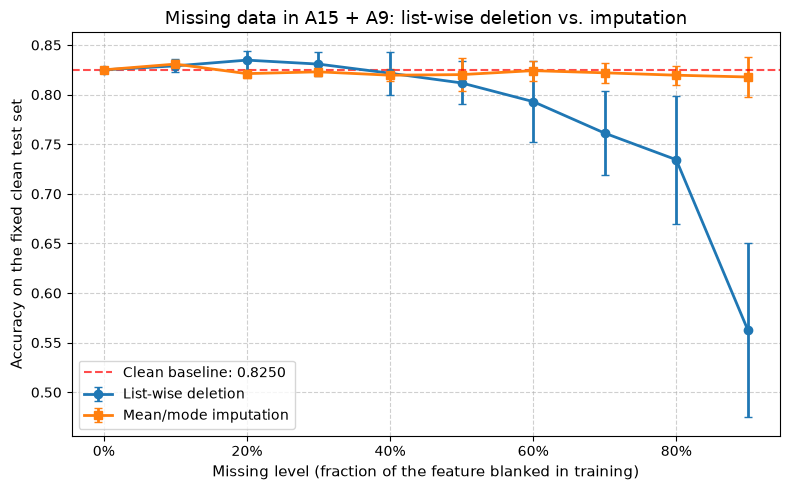

In [5]:
res_main = run_missing_data_experiment(['A15', 'A9'])
print(res_main.to_string(index=False,
      formatters={c: (lambda v: f'{v:.4f}') for c in res_main.columns if c != 'train_rows_kept'}))

plot_missing_data_experiment(
    res_main,
    'Missing data in A15 + A9: list-wise deletion vs. imputation',
    save_path='images/ex06_fig1.png',
)


## 5. Deletion does not care *which* feature is missing

List-wise deletion only removes rows, so its accuracy depends on *how many* training rows
survive, not on which column was blanked. To show this we run the experiment once for
`A15` alone and once for `A9` alone: the two deletion curves land on top of each other,
while only the imputation curves differ.


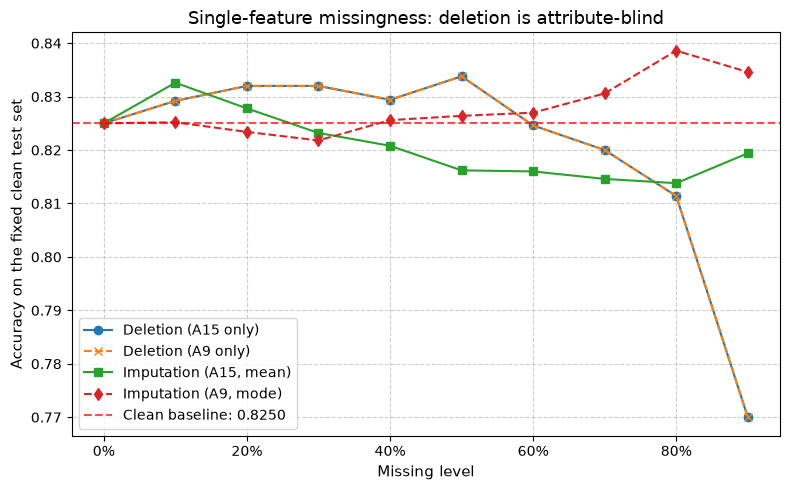

Deletion curves identical for A15-only vs A9-only: True


In [6]:
res_a15 = run_missing_data_experiment(['A15'])
res_a9 = run_missing_data_experiment(['A9'])

plt.figure(figsize=(8, 5))
plt.plot(res_a15['missing_level'], res_a15['deletion_mean'], 'o-', label='Deletion (A15 only)')
plt.plot(res_a9['missing_level'], res_a9['deletion_mean'], 'x--', label='Deletion (A9 only)')
plt.plot(res_a15['missing_level'], res_a15['imputation_mean'], 's-', label='Imputation (A15, mean)')
plt.plot(res_a9['missing_level'], res_a9['imputation_mean'], 'd--', label='Imputation (A9, mode)')
plt.axhline(BASELINE_ACC, color='red', linestyle='--', alpha=0.7, label=f'Clean baseline: {BASELINE_ACC:.4f}')
plt.title('Single-feature missingness: deletion is attribute-blind', fontsize=13)
plt.xlabel('Missing level', fontsize=11)
plt.ylabel('Accuracy on the fixed clean test set', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(round(v * 100))}%'))
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('images/ex06_fig2.png', dpi=110, bbox_inches='tight')
plt.show()

print('Deletion curves identical for A15-only vs A9-only:',
      np.allclose(res_a15['deletion_mean'], res_a9['deletion_mean']))


## Experiment interpretation

We make one fixed 70/30 split and keep the test set clean for every run. Missing values
are introduced only in the training features, at levels from 0% to 90%, and every point is
averaged over 25 seeds (error bars = standard deviation). At each level we clean the
training set two ways and score both on the same clean test set:

- **List-wise deletion** - drop every training row that has a missing value in a target column.
- **Mean/mode imputation** - fill missing values with the mean (numerical) or mode (categorical) of the corrupted training column.

Holding the test set fixed is the correction to our first attempt, where we corrupted the
whole dataset before splitting: there the test set shrank and changed at every level, so
most of the wobble in the curves was a moving benchmark rather than an effect of the
cleaning strategy.


## Takeaways

**Target features:** `A15` (income) and `A9` (prior default) - the two attributes the model
actually uses (Exercise 1). Both strategies start from the same 0.825 clean baseline.

**What we saw**

- **Imputation is almost flat** across the whole range: even at 90% missing on both
  features it holds ~0.82, with small error bars.
- **Deletion holds up to ~30% missing, then falls off a cliff** - ~0.81 at 50%, ~0.76 at
  70%, and ~0.56 at 90%, when only a handful of training rows survive. Its error bars blow
  up as the surviving sample shrinks.
- The two single-feature **deletion curves (A15-only and A9-only) are identical**; only the
  imputation curves depend on which feature was blanked.

**Why**

- Deletion never looks at the feature, it only removes rows, so its accuracy is a function
  of *how many* training rows are left - not which column was blanked. It breaks only when
  the surviving sample is too small to estimate the class distributions.
- Imputation keeps all ~466 training rows. Filling with the mean/mode makes the corrupted
  feature nearly constant rather than wrong, and a near-constant feature is one GaussianNB
  effectively ignores - so the model quietly leans on the other features and barely moves.
- Compare with Exercise 1: replacing `A9` with *random* categories dropped accuracy to
  ~0.76, but mode-imputing the same fraction barely moves it. Same amount of lost
  information, opposite effect - a constant is ignorable, random noise is misleading.

**Practical implication**

- List-wise deletion is only safe when missingness is rare; once a large share of rows are
  affected it throws away too much data. Mean/mode imputation degrades gracefully, at the
  cost of flattening the affected feature.
- To compare cleaning strategies fairly, keep the test set fixed and complete and only
  corrupt/clean the training side.
